In [1]:
#ДЗ 
# 1. Для изображения sar_3.jpg найти наиболее протяженный участок
# (выделить линии при помощи преобразования Хафа)
# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

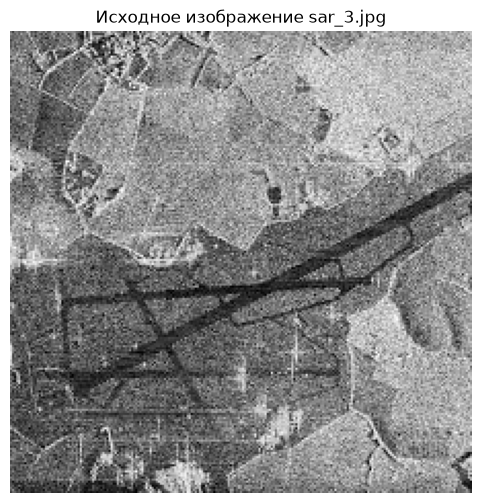

In [2]:
## Пункт 1. Загрузка исходного изображения

import numpy as np
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 6))
plt.imshow(image_gray, cmap='gray')
plt.title('Исходное изображение sar_3.jpg')
plt.axis('off')
plt.show()

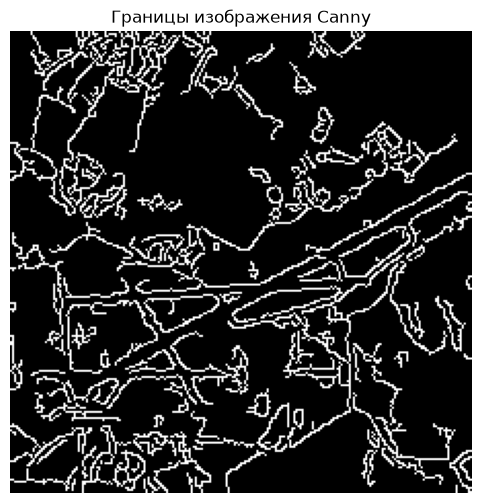

In [3]:
## Пункт 2. Выделение границ оператором Canny

blurred = cv2.GaussianBlur(image_gray, (5, 5), 0)

edges = cv2.Canny(blurred, 70, 180)

plt.figure(figsize=(10, 6))
plt.imshow(edges, cmap='gray')
plt.title('Границы изображения Canny')
plt.axis('off')
plt.show()

Длина наиболее протяжённого участка: 245.59 пикселей


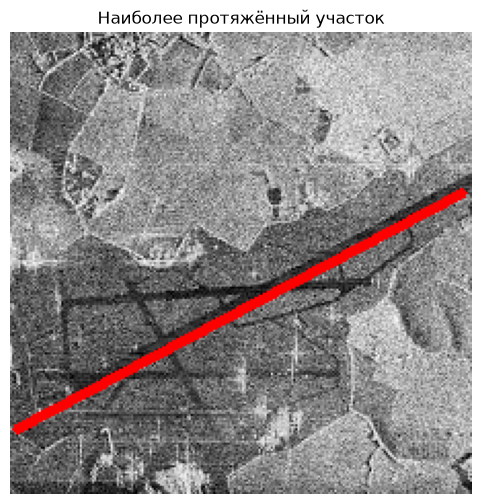

In [4]:
## Пункт 3. Поиск наиболее протяжённого участка с помощью преобразования Хафа

lines = cv2.HoughLinesP(
    edges,
    1,
    np.pi / 180,
    threshold=80,
    minLineLength=100,
    maxLineGap=20
)

image_lines = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2BGR)

if lines is not None:
    lines = lines.reshape(-1, 4)

    longest_line = max(
        lines,
        key=lambda line: np.sqrt(
            (line[2] - line[0]) ** 2 +
            (line[3] - line[1]) ** 2
        )
    )

    x1, y1, x2, y2 = longest_line

    length = np.sqrt(
        (x2 - x1) ** 2 +
        (y2 - y1) ** 2
    )

    cv2.line(
        image_lines,
        (x1, y1),
        (x2, y2),
        (0, 0, 255),
        3
    )

    print(f'Длина наиболее протяжённого участка: {length:.2f} пикселей')

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(image_lines, cv2.COLOR_BGR2RGB))
plt.title('Наиболее протяжённый участок')
plt.axis('off')
plt.show()

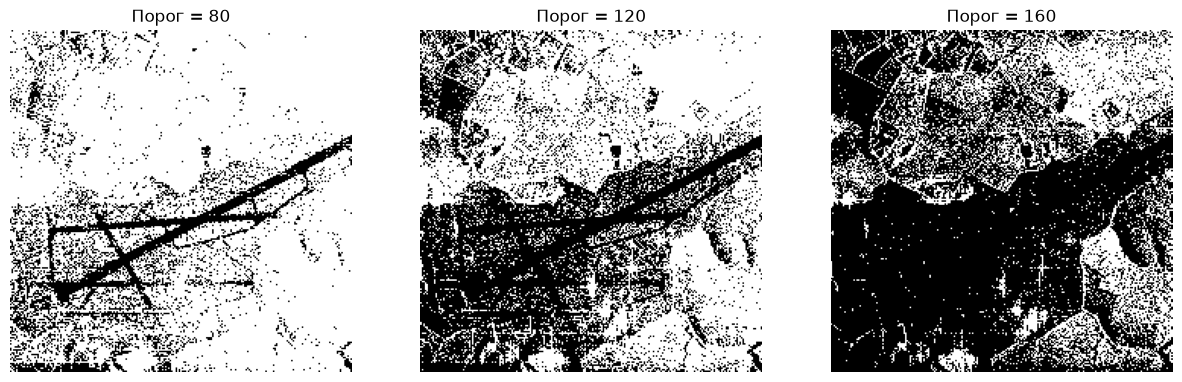

In [5]:
## Пункт 4. Пороговая бинаризация с различными значениями порога

_, binary_80 = cv2.threshold(image_gray, 80, 255, cv2.THRESH_BINARY)
_, binary_120 = cv2.threshold(image_gray, 120, 255, cv2.THRESH_BINARY)
_, binary_160 = cv2.threshold(image_gray, 160, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(binary_80, cmap='gray')
plt.title('Порог = 80')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(binary_120, cmap='gray')
plt.title('Порог = 120')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(binary_160, cmap='gray')
plt.title('Порог = 160')
plt.axis('off')

plt.show()

Автоматически выбранный порог Отсу: 129.00


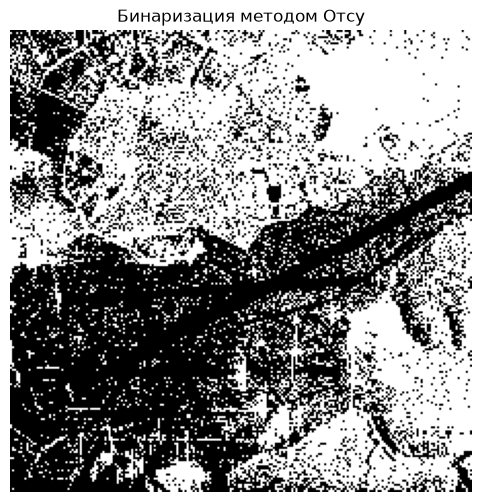

In [6]:
## Пункт 5. Бинаризация методом Отсу

threshold_otsu, binary_otsu = cv2.threshold(
    image_gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print(f'Автоматически выбранный порог Отсу: {threshold_otsu:.2f}')

plt.figure(figsize=(10, 6))
plt.imshow(binary_otsu, cmap='gray')
plt.title('Бинаризация методом Отсу')
plt.axis('off')
plt.show()

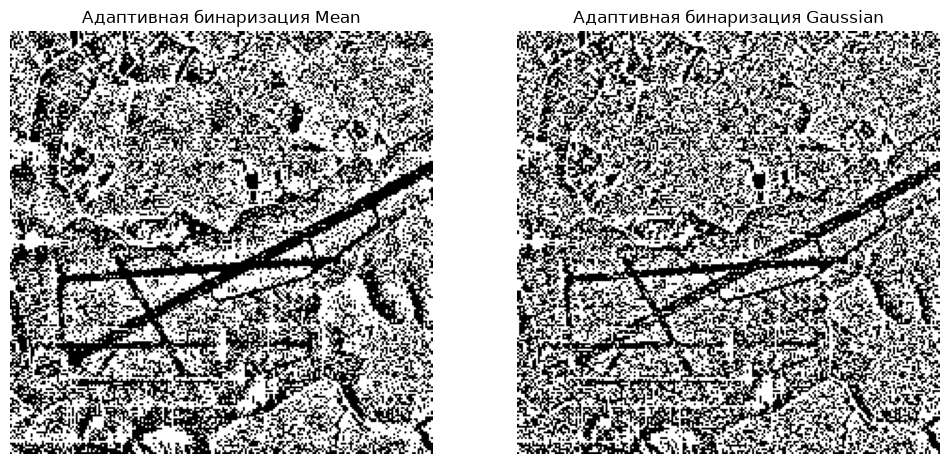

In [7]:
## Пункт 6. Адаптивная бинаризация

adaptive_mean = cv2.adaptiveThreshold(
    image_gray,
    255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    21,
    5
)

adaptive_gauss = cv2.adaptiveThreshold(
    image_gray,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    21,
    5
)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(adaptive_mean, cmap='gray')
plt.title('Адаптивная бинаризация Mean')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(adaptive_gauss, cmap='gray')
plt.title('Адаптивная бинаризация Gaussian')
plt.axis('off')

plt.show()

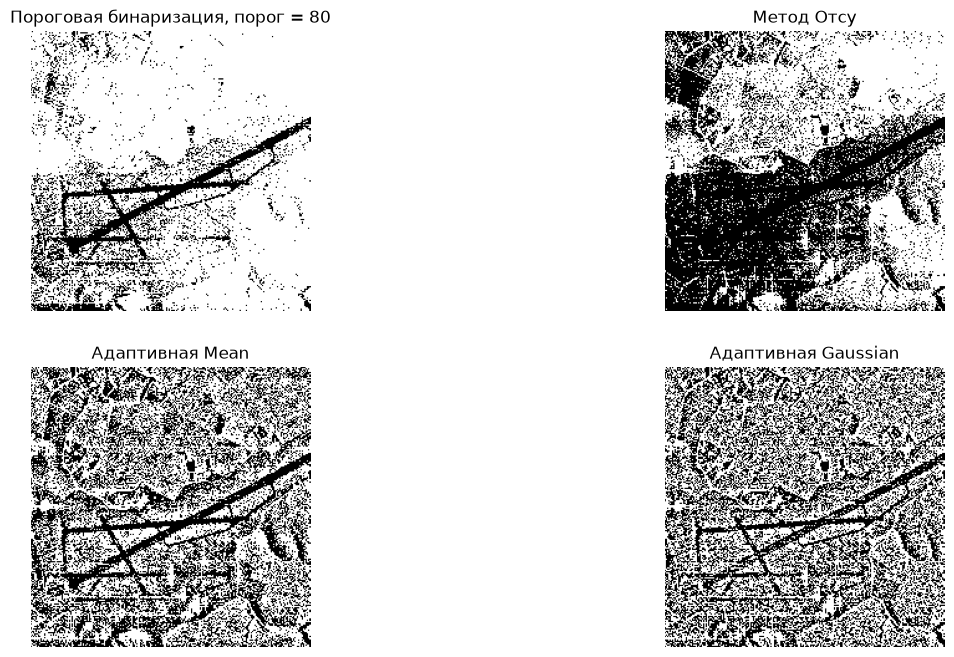

Лучший результат для выделения дорожной полосы: пороговая бинаризация с порогом 80.


In [8]:
## Пункт 7. Сравнение методов бинаризации

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(binary_80, cmap='gray')
plt.title('Пороговая бинаризация, порог = 80')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(binary_otsu, cmap='gray')
plt.title('Метод Отсу')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(adaptive_mean, cmap='gray')
plt.title('Адаптивная Mean')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(adaptive_gauss, cmap='gray')
plt.title('Адаптивная Gaussian')
plt.axis('off')

plt.show()

print('Лучший результат для выделения дорожной полосы: пороговая бинаризация с порогом 80.')

In [9]:
## Пункт 8. Итог

print('Итог работы:')
print('1. С помощью преобразования Хафа был найден наиболее протяжённый линейный участок.')
print('2. Были исследованы пороговая бинаризация, метод Отсу и адаптивная бинаризация.')
print('3. Для данного изображения лучший результат выделения дорожной полосы дала пороговая бинаризация с порогом 80.')

Итог работы:
1. С помощью преобразования Хафа был найден наиболее протяжённый линейный участок.
2. Были исследованы пороговая бинаризация, метод Отсу и адаптивная бинаризация.
3. Для данного изображения лучший результат выделения дорожной полосы дала пороговая бинаризация с порогом 80.
